### ECG200 
In this data set, each series traces the electrical activity recorded during one heartbeat. The two classes are a normal heartbeat versus a myocardial infarction event (heart attack due to prolonged cardiac ischemia).
http://www.timeseriesclassification.com/description.php?Dataset=ECG200

In [1]:

import pandas as pd
import numpy as np

# Load the ECG200 dataset from the UCR archive
ECG200_train = pd.read_csv('UCRArchive_2018/ECG200/ECG200_TRAIN.tsv', header=None, sep='\t')
ECG200_train = ECG200_train.iloc[:50]
print(ECG200_train.head())

ECG200_test = pd.read_csv('UCRArchive_2018/ECG200/ECG200_TEST.tsv', header=None, sep='\t')
ECG200_test = ECG200_train.iloc[:50]
print(ECG200_test.head())

# Here we prepare the data for the model
X_train = ECG200_train.iloc[:, 1:].values
Y_train = ECG200_train[0].values
X_test = ECG200_test.iloc[:, 1:].values
Y_test = ECG200_test[0].values


   0         1         2         3         4         5         6         7   \
0  -1  0.502055  0.542163  0.722383  1.428885  2.136516  2.281149  1.936274   
1   1  0.147647  0.804668  0.367771  0.243894  0.026614 -0.274402  0.096731   
2  -1  0.316646  0.243199  0.370471  1.063738  1.678187  1.759558  1.697717   
3  -1  1.168874  2.075901  1.760141  1.606446  1.949046  1.302842  0.459332   
4   1  0.648658  0.752026  2.636231  3.455716  2.118157  0.520620 -0.188627   

         8         9   ...        87        88        89        90        91  \
0  1.468890  1.008845  ...  0.931043  0.610298  0.638894  0.684679  0.583238   
1 -0.747731 -1.609777  ... -0.533503 -0.400228  0.176084  1.111768  2.438428   
2  1.612159  1.168188  ...  0.764229  0.610621  0.552900  0.566786  0.604002   
3  0.516412  0.852180  ...  0.419006  0.723888  1.323947  2.136488  1.746597   
4  0.780818  0.933775  ... -0.097869 -0.136787 -0.340237 -0.089441 -0.080297   

         92        93        94        95   

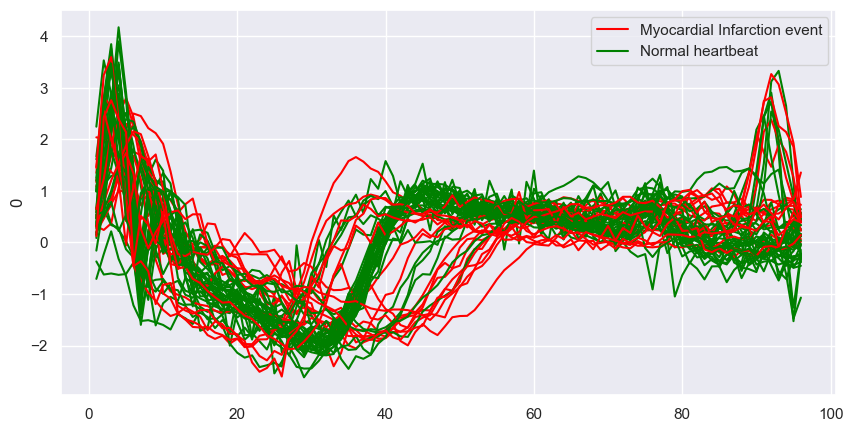

In [2]:
# Here we visualize the data to get a better understanding of it
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="darkgrid")
plt.figure(figsize=(10, 5))

normal_label_added = False
mi_label_added = False

for i in range(len(ECG200_train)):
    if ECG200_train.iloc[i, 0] == 1:
        if not normal_label_added:
            sns.lineplot(data=ECG200_train.iloc[i, 1:], color='green', label='Normal heartbeat')
            normal_label_added = True
        else:
            sns.lineplot(data=ECG200_train.iloc[i, 1:], color='green')
    else:
        if not mi_label_added:
            sns.lineplot(data=ECG200_train.iloc[i, 1:], color='red', label='Myocardial Infarction event')
            mi_label_added = True
        else:
            sns.lineplot(data=ECG200_train.iloc[i, 1:], color='red')

plt.legend()
plt.show()

In [4]:
#Here we create the distance matrix for ECG200 dataset using DTW(Dynamic Time Wraping)
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
distance_matrix = np.zeros((len(ECG200_train), len(ECG200_train)))
for i in range(len(ECG200_train)):
    for j in range(len(ECG200_train)):
        distance_matrix[i, j] = fastdtw(ECG200_train.loc[i, 1:].values.reshape(-1, 1), 
                                        ECG200_train.loc[j, 1:].values.reshape(-1, 1),
                                        dist=euclidean)[0] #we put [o] to get only the distance and not the path
print(distance_matrix)
distance_matrix.shape


[[ 0.         52.42591632 10.60136143 ... 26.8778286  29.4333571
  23.84865139]
 [52.42591632  0.         50.55041241 ... 48.65084397 44.75335575
  53.35959342]
 [10.60136143 50.55041241  0.         ... 38.29889356 28.32058517
  25.1077191 ]
 ...
 [26.8778286  48.65084397 38.29889356 ...  0.         40.01271397
  35.91962343]
 [29.4333571  44.75335575 28.32058517 ... 40.01271397  0.
  19.37073216]
 [23.84865139 53.35959342 25.1077191  ... 35.91962343 19.37073216
   0.        ]]


(50, 50)

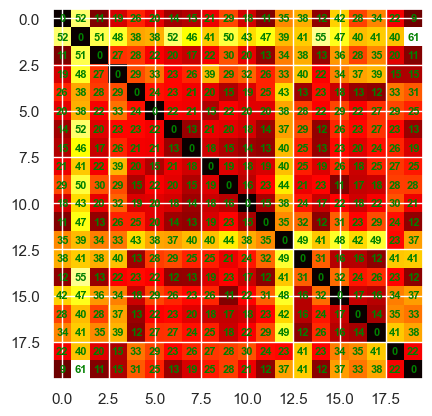

In [5]:
# Here we visualize a 20x20 subset of the distance matrix for the ECG200 dataset 
import matplotlib.pyplot as plt
plt.imshow(distance_matrix[:20, :20], cmap='hot', interpolation='nearest')

# Display the numbers in each cell
for i in range(20):
    for j in range(20):
        plt.text(j, i, "{:.0f}".format(distance_matrix[i, j]), ha='center', va='center', color='green', fontsize=8, fontweight='bold')

plt.show()

### Time series distances: training the model
Let's imagine that we want to monitor Fitbit's time series data of sleep for 3 hours or heart rate for 5 hours. For example, if we take the heart rate data of all patients over a one-hour period, we first select a time series and set a threshold. The series that is more similar to the selected one is placed on the right side of the decision tree, while less similar series are placed on the left. The challenge lies in determining this threshold.

To address this, we identify a reference time series, or "witness," and measure the distance between it and other series. These distances are then used to order the time series. The goal is to assign labels, such as +1 or -1 (e.g., good sleep vs. bad sleep), based on their contribution to maximizing information gain. After calculating the information gain for each threshold, we apply this process to all time series and select the one with the highest overall information gain. The final consideration is determining the length of time for which these series should be analyzed, with all time series being standardized to equal lengths to ensure consistency in analysis.

In [6]:
#Two Functions for generating the witness time series and determining the optimal threshold

def generate_witness(X, Y, DM, Loss):
    """
    Generate the witness time series and determine the optimal threshold.
    
    Parameters:
    - X: Time series data.
    - Y: Labels corresponding to time series.
    - DM: Distance matrix between the time series.
    - Loss: Loss function to evaluate the cut.
    
    Returns:
    - max_loss: Maximum loss value achieved.
    - wts: Index of the selected witness time series.
    - wth: Threshold that maximizes the information gain.
    """
    max_loss = 0
    wts, wth = None, None

    for i in range(len(X)):
        value, threshold = best_cut(i, Y, DM, Loss)
        if value > max_loss:
            max_loss = value
            wts = X[i]
            wth = threshold
            
    return max_loss, wts, wth


def best_cut(idx, Y, DM, Loss):
    """
    Determine the best cut for a given time series index.
    
    Parameters:
    - idx: Index of the time series.
    - Y: Labels corresponding to time series.
    - DM: Distance matrix between the time series.
    - Loss: Loss function to evaluate the cut.
    
    Returns:
    - loss_value: The maximum loss value obtained by the best cut.
    - threshold: The threshold value at the best cut.
    """
    # Create pairs of (distance, label)
    pairs = [(DM[j, idx], Y[j]) for j in range(len(Y))]
    
    # Sort pairs based on distance
    pairs.sort(key=lambda x: x[0])
    
    # Compute loss values for each possible cut
    loss_values = [Loss([p[1] for p in pairs[:j]], [p[1] for p in pairs[j:]]) for j in range(1, len(Y))]
    
    # Find the index of the maximum loss value
    j = np.argmax(loss_values)
    
    # Compute the threshold
    threshold = (pairs[j][0] + pairs[j-1][0])/2

    return loss_values[j], threshold

#Function for calculating the loss using Gini impurity
def Gini(group1, group2):
    _, counts1 = np.unique(group1, return_counts=True)
    _, counts2 = np.unique(group2, return_counts=True)
    gini1 = 1 - sum((count / len(group1)) ** 2 for count in counts1)
    gini2 = 1 - sum((count / len(group2)) ** 2 for count in counts2)
    return gini1 + gini2


#Function for calculating the loss using entropy
def InformationGain(group1, group2):
    # Compute the entropy of a group
    def entropy(group):
        _, counts = np.unique(group, return_counts=True)
        probs = counts / len(group)
        return -sum(p * np.log2(p) for p in probs)
    
    # Compute the information gain
    entropy_before = entropy(group1 + group2)
    entropy_after = (len(group1) * entropy(group1) + len(group2) * entropy(group2)) / (len(group1) + len(group2))
    return entropy_before - entropy_after


In [7]:
generate_witness(X_train, Y_train, DM = distance_matrix, Loss=InformationGain)

(0.33984949701936384,
 array([ 1.1688741 ,  2.0759008 ,  1.7601405 ,  1.6064459 ,  1.9490456 ,
         1.3028421 ,  0.45933154,  0.51641212,  0.85217953,  0.98922717,
         0.82125349,  0.57644764,  0.74308944,  0.8529702 ,  0.30745835,
        -0.13039065, -0.06219997, -0.10072696, -0.23281819, -0.23446477,
        -0.21475573, -0.23041257, -0.22755149, -0.23100238, -0.46347873,
        -0.72421462, -0.78788488, -0.98668657, -1.224672  , -1.2881418 ,
        -1.3641481 , -1.4282213 , -1.5017669 , -1.6480837 , -1.7058362 ,
        -1.6867905 , -1.7057193 , -1.7776833 , -1.8693132 , -1.8583761 ,
        -1.7377167 , -1.7291486 , -1.7281054 , -1.5460373 , -1.4591025 ,
        -1.4107518 , -1.1634273 , -0.90741874, -0.71621062, -0.58176337,
        -0.44252605, -0.20704617, -0.02646266,  0.11703627,  0.22063662,
         0.26431516,  0.40505498,  0.46497434,  0.43416264,  0.4868072 ,
         0.43938773,  0.36961087,  0.41314866,  0.3978947 ,  0.31876371,
         0.26371736,  0.28886

#### What Generate Witness returns:
1. **max_loss**: The maximum loss value obtained from the loss function. This value represents the best "cut" or separation of the data.

2. **wts**: The witness time series, that is the index of the time series that resulted in the maximum information gain. In other words, if you were to separate your data based on the distances to this time series, you would get the maximum information gain.

3. **wth**: This is the threshold distance for the best cut. If you were to separate your data into two groups - one with distances to the **wts**'th time series less than this value, and one with distances greater than or equal to this value - you would get the maximum information gain.

#### A decision tree visualized with class distribution in each node

In [8]:
def TS_Tree_Train(X, Y, maxd=10, mins=2):
    """
    Trains a Time Series Tree using the given input data.

    Parameters:
    X (numpy.ndarray): The input time series data.
    Y (numpy.ndarray): The corresponding labels for the time series data.
    maxd (int): The maximum depth of the tree.
    mins (int): The minimum number of samples for splitting.

    Returns:
    Node: The root node of the trained Time Series Tree.
    """
    def frequencies(Y):
        unique, counts = np.unique(Y, return_counts=True)
        return dict(zip(unique, counts))
    
    def Compute_Distance_Matrix(X):
        distance_matrix = np.zeros((len(X), len(X)))
        for i in range(len(X)):
            for j in range(len(X)):
                distance_matrix[i, j] = fastdtw(X[i].reshape(-1, 1), X[j].reshape(-1, 1), dist=euclidean)[0]
        return distance_matrix
    
    def Find_Witness(DM, Y):
        max_loss = 0
        wts, wth = None, None

        for i in range(len(X)):
            value, threshold = best_cut(i, Y, DM, InformationGain)
            if value > max_loss:
                max_loss = value
                wts = X[i]
                wth = threshold

        return max_loss, wts, wth
    
    def best_cut(idx, Y, DM, Loss):
        pairs = [(DM[j, idx], Y[j]) for j in range(len(Y))]
        pairs.sort(key=lambda x: x[0])
        loss_values = [Loss([p[1] for p in pairs[:j]], [p[1] for p in pairs[j:]]) for j in range(1, len(Y))]
        j = np.argmax(loss_values)
        threshold = (pairs[j][0] + pairs[j-1][0])/2

        return loss_values[j], threshold
    
    class Node:
        def __init__(self, wts, threshold, class_distribution):
            self.wts = wts
            self.threshold = threshold
            self.class_distribution = class_distribution
            self.TrueChild = None
            self.FalseChild = None
    
    if len(set(Y)) == 1 or maxd == 0 or len(X) < mins:
        return Node(None, None, frequencies(Y))
    else:
        DM = Compute_Distance_Matrix(X)
        Ig, wts, threshold = Find_Witness(DM, Y)
        if Ig == 0:
            return Node(None, None, frequencies(Y))
        else:
            node = Node(wts, threshold, None)
            TrueIndexes = [i for i in range(len(X)) if fastdtw(wts.reshape(-1, 1), X[i].reshape(-1, 1), dist=euclidean)[0] <= threshold]
            FalseIndexes = [i for i in range(len(X)) if i not in TrueIndexes]
            node.TrueChild = TS_Tree_Train(X[TrueIndexes], Y[TrueIndexes], maxd-1, mins)
            node.FalseChild = TS_Tree_Train(X[FalseIndexes], Y[FalseIndexes], maxd-1, mins)
            return node


In [9]:
#Function for predicting the labels of the test data

def TS_Tree_Predict(X, node):
    """
    Predicts the labels for the given input data using the trained Time Series Tree.

    Parameters:
    X (numpy.ndarray): The input time series data.
    node (Node): The root node of the trained Time Series Tree.

    Returns:
    numpy.ndarray: The predicted labels for the input data.
    """
    def Predict(x, node):
        if node.class_distribution != None:
            return max(node.class_distribution, key=node.class_distribution.get)
        else:
            if fastdtw(node.wts.reshape(-1, 1), x.reshape(-1, 1), dist=euclidean)[0] <= node.threshold:
                return Predict(x, node.TrueChild)
            else:
                return Predict(x, node.FalseChild)
    
    return np.array([Predict(x, node) for x in X])

In [10]:
# Here we train the Time Series Tree using the ECG200 dataset and make predictions on the test data
Train_example = TS_Tree_Train(X_train, Y_train, 7, 2)

# Make predictions on the test data
Test_example = TS_Tree_Predict(X_test, Train_example)
print(Test_example)

[-1  1 -1 -1  1  1 -1 -1  1  1  1  1  1  1 -1  1  1  1 -1 -1  1  1  1 -1
  1  1  1 -1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1 -1  1 -1 -1
  1 -1]


In [11]:
# Here we evaluate the test performance of the model using the accuracy, precision, recall, and F1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(Y_test, Test_example)
precision = precision_score(Y_test, Test_example)
recall = recall_score(Y_test, Test_example)
f1 = f1_score(Y_test, Test_example)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


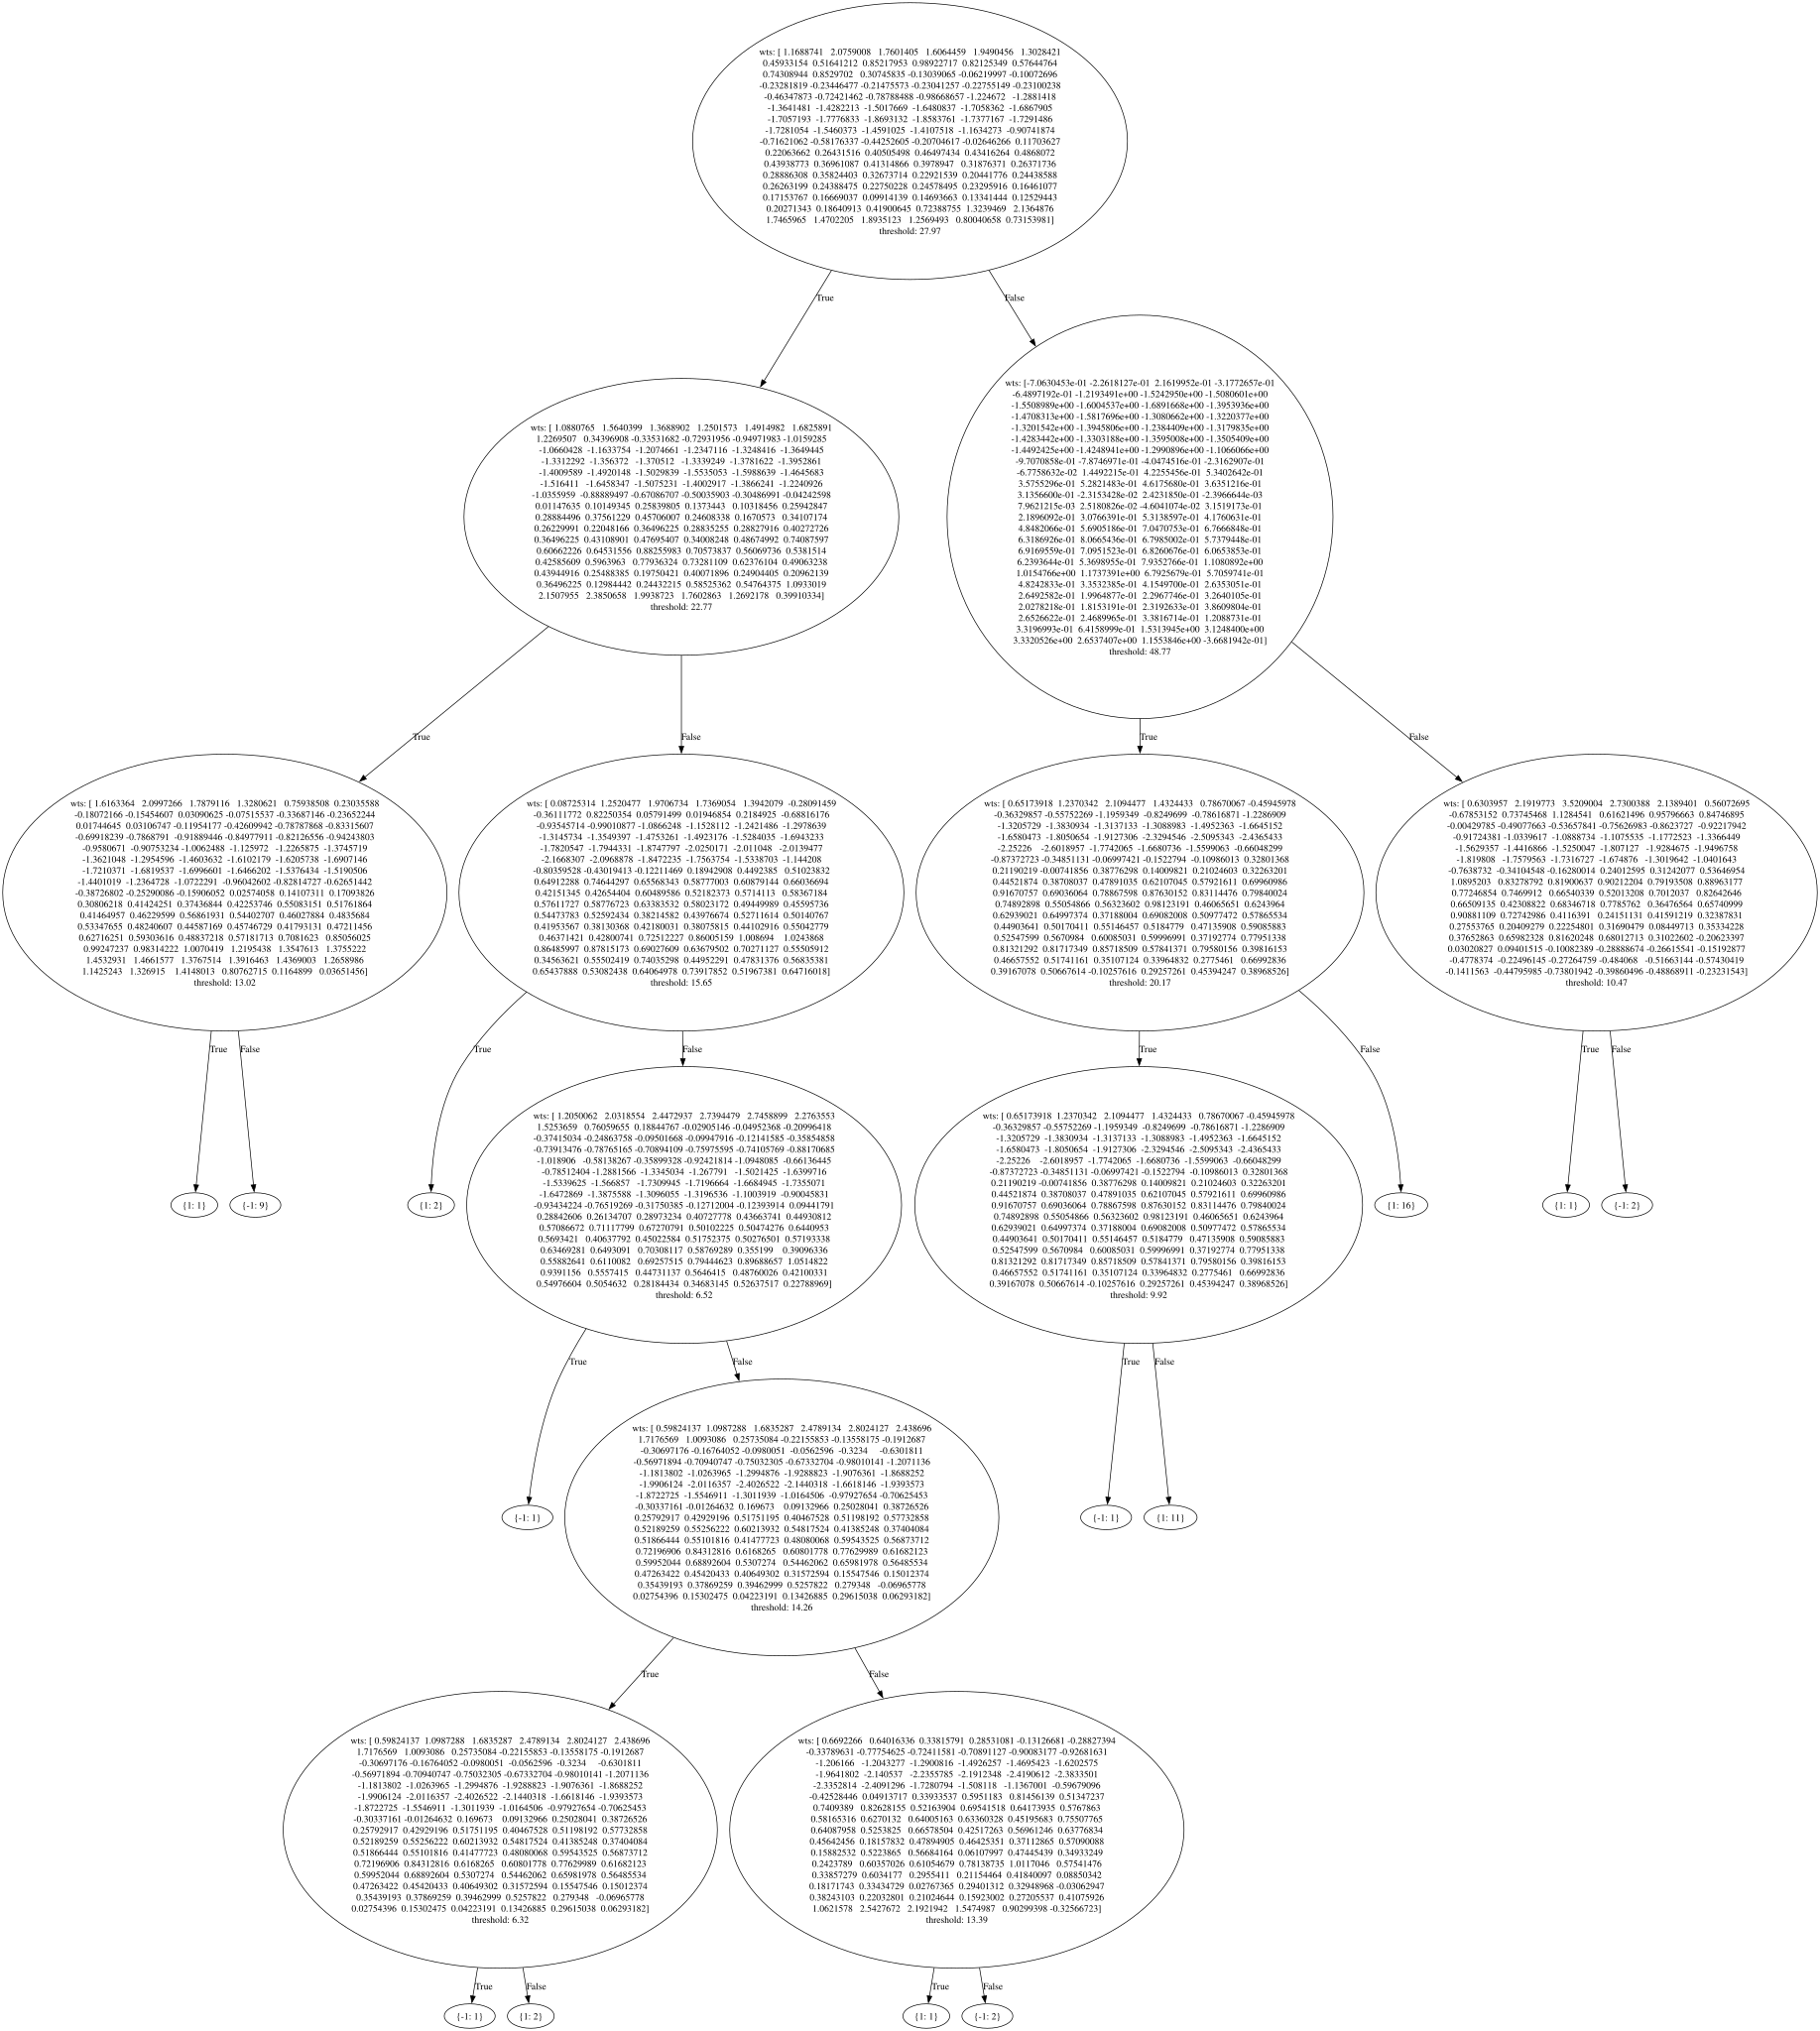

In [12]:
#here we will use a visualization function to visualize the tree
import graphviz

def visualize_tree(node, dot=None):
    if dot is None:
        dot = graphviz.Digraph()
    
    if node.class_distribution != None:
        dot.node(str(id(node)), label=str(node.class_distribution))
    else:
        dot.node(str(id(node)), label='wts: {}\nthreshold: {:.2f}'.format(node.wts, node.threshold))
        if node.TrueChild != None:
            dot.edge(str(id(node)), str(id(node.TrueChild)), label='True')
            visualize_tree(node.TrueChild, dot)
        if node.FalseChild != None:
            dot.edge(str(id(node)), str(id(node.FalseChild)), label='False')
            visualize_tree(node.FalseChild, dot)
    
    return dot

dot = visualize_tree(Train_example)
dot.render('TS_Tree', format='png', cleanup=True)
dot

In [15]:
#Now let's do a grid search to find the best hyperparameters for the Time Series Tree model
from sklearn.model_selection import ParameterGrid

# Define the hyperparameters to search
param_grid = {
    'maxd': [3, 15],
    'mins': [2]
}

# Generate all possible combinations of hyperparameters
grid = ParameterGrid(param_grid)

# Train the Time Series Tree model for each hyperparameter combination
results = []
for params in grid:
    Train_example = TS_Tree_Train(X_train, Y_train, params['maxd'], params['mins'])
    Test_example = TS_Tree_Predict(X_test, Train_example)
    accuracy = accuracy_score(Y_test, Test_example)
    precision = precision_score(Y_test, Test_example)
    recall = recall_score(Y_test, Test_example)
    f1 = f1_score(Y_test, Test_example)
    results.append({
        'maxd': params['maxd'],
        'mins': params['mins'],
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

# Display the results
results_df = pd.DataFrame(results)
print(results_df)


   maxd  mins  accuracy  precision    recall        f1
0     3     2      0.92    0.96875  0.911765  0.939394
1    15     2      1.00    1.00000  1.000000  1.000000


In [16]:
#lets do the random forest classifier on the dataset and compare the results
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

# Make predictions on the test data
rf_predictions = rf.predict(X_test)

# Evaluate the test performance of the Random Forest model
accuracy = accuracy_score(Y_test, rf_predictions)
precision = precision_score(Y_test, rf_predictions)
recall = recall_score(Y_test, rf_predictions)
f1 = f1_score(Y_test, rf_predictions)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


In [13]:
#Now let's create a random forest on our time series tree model
def TS_Tree_Random_Forest(X, Y, n_trees=5, maxd=8, mins=2):
    """
    Trains a Random Forest model using the Time Series Tree algorithm.

    Parameters:
    X (numpy.ndarray): The input time series data.
    Y (numpy.ndarray): The corresponding labels for the time series data.
    n_trees (int): The number of trees in the Random Forest.
    maxd (int): The maximum depth of the tree.
    mins (int): The minimum number of samples for splitting.

    Returns:
    list: A list of trained Time Series Trees.
    """
    trees = []
    for _ in range(n_trees):
        # Randomly sample the data with replacement
        idx = np.random.choice(len(X), len(X), replace=True)
        X_sample = X[idx]
        Y_sample = Y[idx]
        
        # Train a Time Series Tree model
        tree = TS_Tree_Train(X_sample, Y_sample, maxd, mins)
        trees.append(tree)
    
    return trees

# Train a Random Forest model using the Time Series Tree algorithm
forest = TS_Tree_Random_Forest(X_train, Y_train, n_trees=5, maxd=12, mins=2)

# Make predictions on the test data
forest_predictions = np.array([TS_Tree_Predict(X_test, tree) for tree in forest])

# Compute the majority vote for each time series
forest_predictions = np.array([max(set(forest_predictions[:, i]), key=list(forest_predictions[:, i]).count) for i in range(len(X_test))])
                              
# Evaluate the test performance of the Random Forest model
accuracy = accuracy_score(Y_test, forest_predictions)
precision = precision_score(Y_test, forest_predictions)
recall = recall_score(Y_test, forest_predictions)
f1 = f1_score(Y_test, forest_predictions)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')

Accuracy: 0.96
Precision: 0.9444444444444444
Recall: 1.0
F1-score: 0.9714285714285714


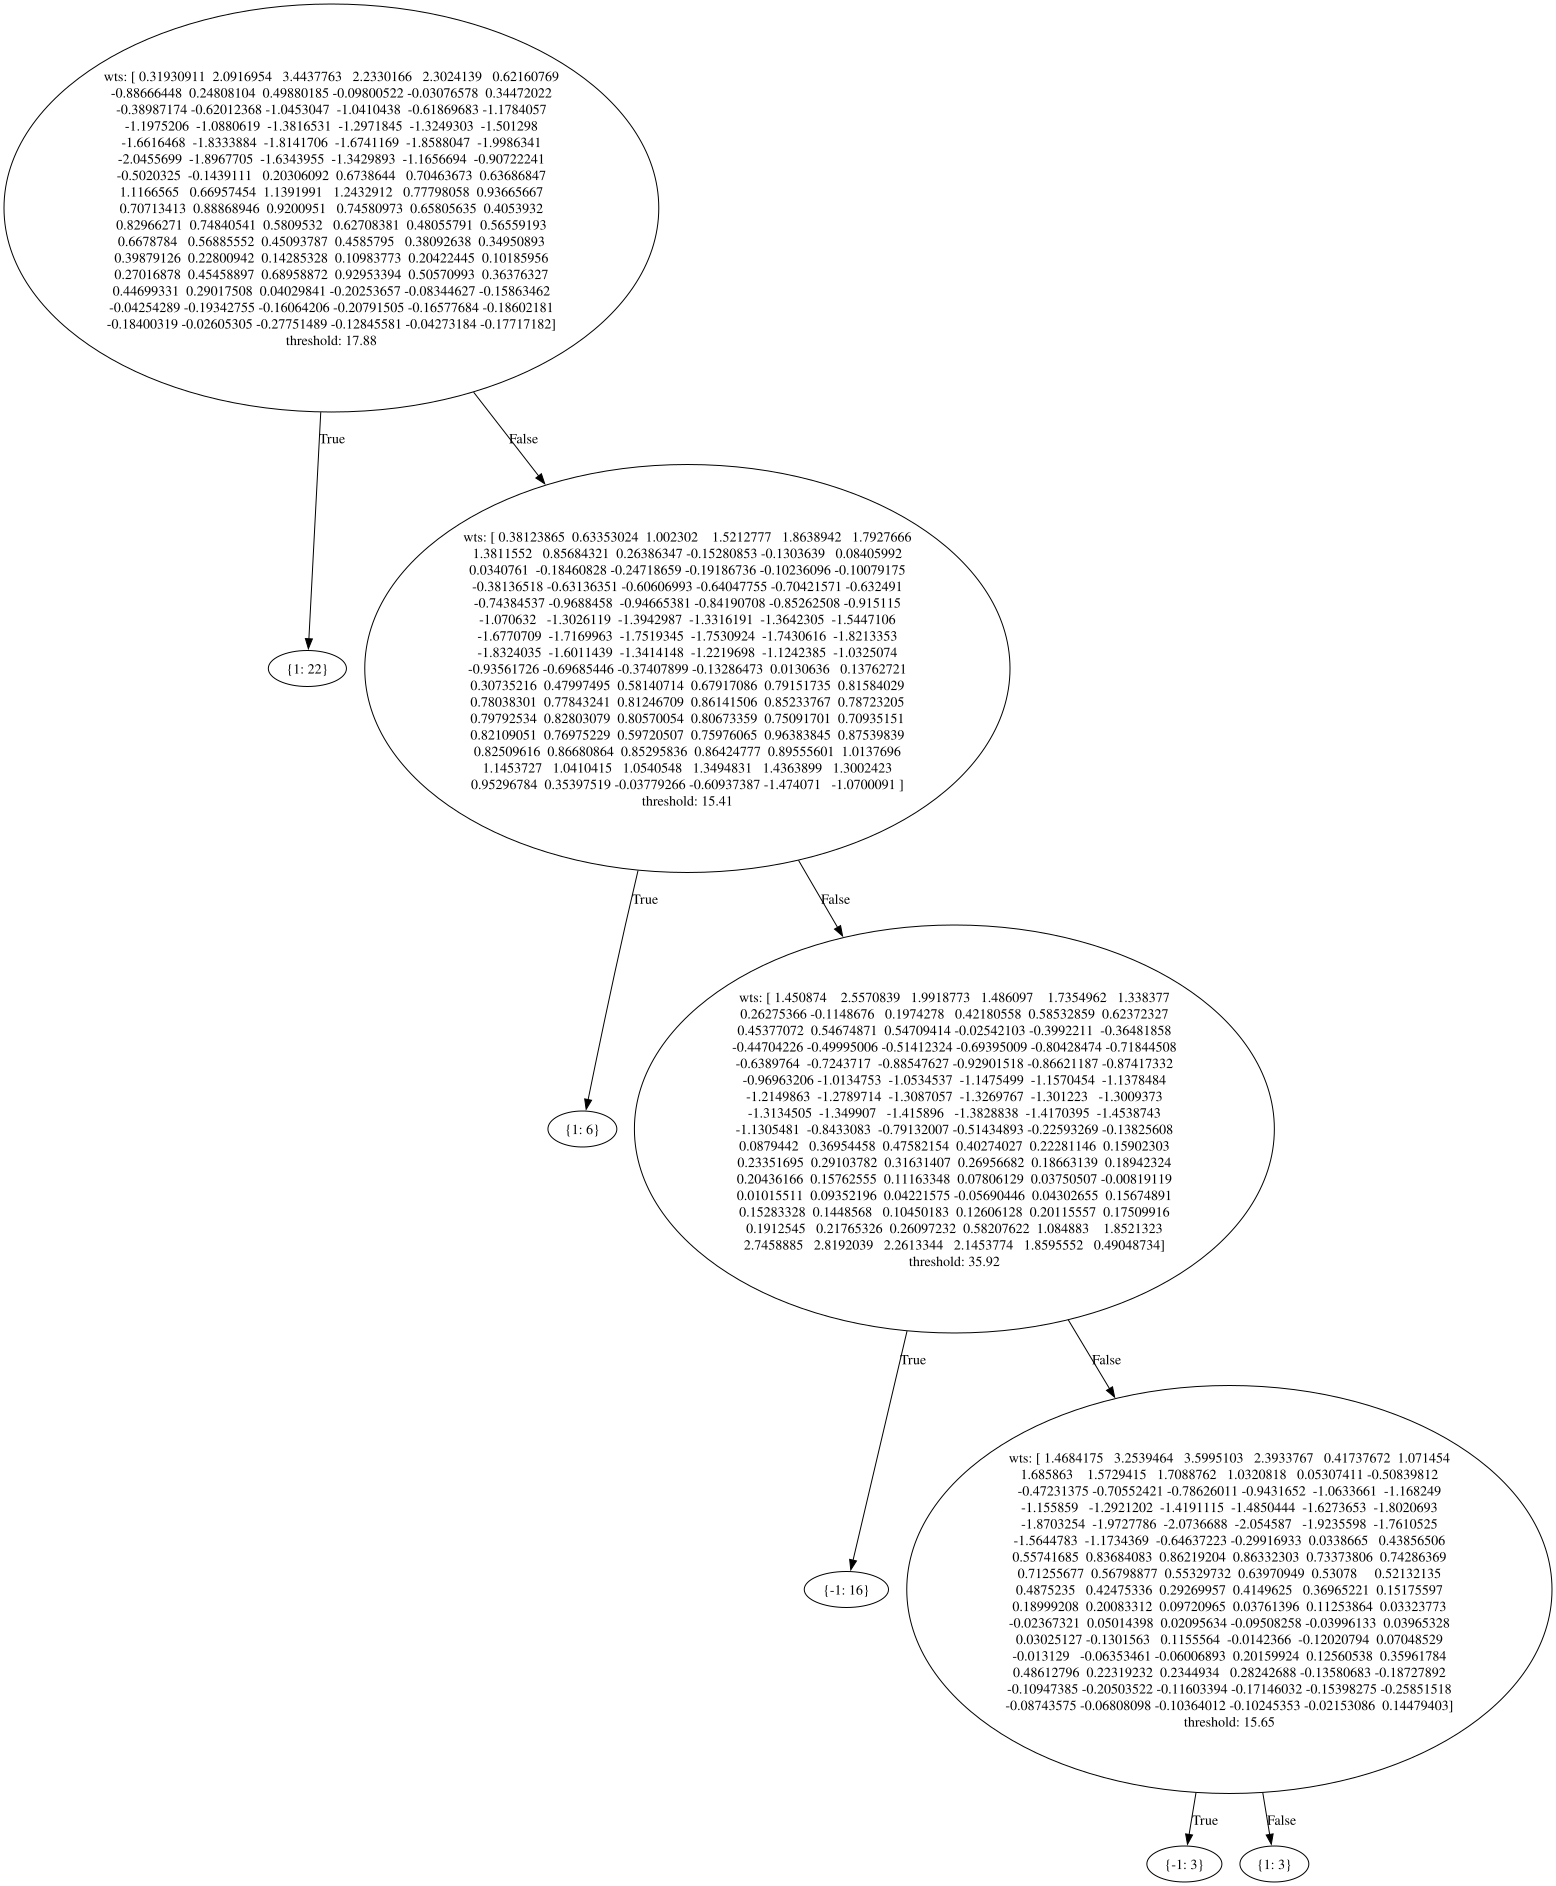

In [14]:
#Now let's visualize the first tree
dot = visualize_tree(forest[0])
dot.render('TS_Random_Forest_Tree', format='png', cleanup=True)
dot

In [19]:
#Now let's do a grid search to find the best hyperparameters for the Random Forest model
# Define the hyperparameters to search
param_grid = {
    'n_trees': [10, 20],
    'maxd': [4, 12],
    'mins': [2]
}

# Generate all possible combinations of hyperparameters
grid = ParameterGrid(param_grid)

# Train the Random Forest model for each hyperparameter combination
results = []

for params in grid:
    forest = TS_Tree_Random_Forest(X_train, Y_train, params['n_trees'], params['maxd'], params['mins'])
    forest_predictions = np.array([TS_Tree_Predict(X_test, tree) for tree in forest])
    forest_predictions = np.array([max(set(forest_predictions[:, i]), key=list(forest_predictions[:, i]).count) for i in range(len(X_test))])
    accuracy = accuracy_score(Y_test, forest_predictions)
    precision = precision_score(Y_test, forest_predictions)
    recall = recall_score(Y_test, forest_predictions)
    f1 = f1_score(Y_test, forest_predictions)
    results.append({
        'n_trees': params['n_trees'],
        'maxd': params['maxd'],
        'mins': params['mins'],
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

# Display the results
results_df = pd.DataFrame(results)
print(results_df)

   n_trees  maxd  mins  accuracy  precision  recall        f1
0       10     4     2      0.98   0.971429     1.0  0.985507
1       20     4     2      0.98   0.971429     1.0  0.985507
2       10    12     2      1.00   1.000000     1.0  1.000000
3       20    12     2      1.00   1.000000     1.0  1.000000


### TS_Step_Tree_Train Function


In [35]:
def TS_Step_Tree_Train(X, Y, maxstep, stepsize, maxd, mins):
    """
    Trains a Time Series Step Tree using the given input data.

    Parameters:
    X (numpy.ndarray): The input time series data.
    Y (numpy.ndarray): The corresponding labels for the time series data.
    maxstep (int): The maximum size of the steps to consider(max features of the dataframe).
    stepsize (int): The size of the steps to consider(number of features to consider in each repitition).
    maxd (int): The maximum depth of the tree.
    mins (int): The minimum number of samples for splitting.

    Returns:
    Node: The root node of the trained Time Series Step Tree.
    """
    def frequencies(Y):
        unique, counts = np.unique(Y, return_counts=True)
        return dict(zip(unique, counts))
    
    def Compute_Distance_Matrix(X):
        distance_matrix = np.zeros((len(X), len(X)))
        for i in range(len(X)):
            for j in range(len(X)):
                distance_matrix[i, j] = fastdtw(X[i].reshape(-1, 1), X[j].reshape(-1, 1), dist=euclidean)[0]
        return distance_matrix
    
    def Find_Witness(DM, Y):
        max_loss = 0
        wts, wth = None, None

        for i in range(len(X)):
            value, threshold = best_cut(i, Y, DM, InformationGain)
            if value > max_loss:
                max_loss = value
                wts = X[i]
                wth = threshold

        return max_loss, wts, wth
    
    def best_cut(idx, Y, DM, Loss):
        pairs = [(DM[j, idx], Y[j]) for j in range(len(Y))]
        pairs.sort(key=lambda x: x[0])
        loss_values = [Loss([p[1] for p in pairs[:j]], [p[1] for p in pairs[j:]]) for j in range(1, len(Y))]
        j = np.argmax(loss_values)
        threshold = (pairs[j][0] + pairs[j-1][0])/2

        return loss_values[j], threshold
    
    class Node:
        def __init__(self, wts, threshold, steps, class_distribution):
            self.wts = wts
            self.threshold = threshold
            self.steps = steps
            self.class_distribution = class_distribution
            self.TrueChild = None
            self.FalseChild = None
    
    if len(set(Y)) == 1 or maxd == 0 or len(X) < mins or min(len(ts) for ts in X) < stepsize:
        return Node(None, None, None, frequencies(Y))
    else:
        real_maxstep = min(maxstep, min(len(ts) for ts in X))
        i = 1
        bestIg = 0
        while i * stepsize <= real_maxstep:
            DM = Compute_Distance_Matrix(X[:, 0:i*stepsize])
            Ig, wts, threshold = Find_Witness(DM, Y)
            if bestIg < Ig:
                bestIg, best_wts, best_threshold, best_steps = Ig, wts[0:i*stepsize], threshold, i*stepsize
            i += 1
        
        if bestIg == 0:
            return Node(None, None, None, frequencies(Y))
        else:
            node = Node(best_wts, best_threshold, best_steps, frequencies(Y))
            TrueIndexes = [i for i in range(0, len(X)) if fastdtw(best_wts.reshape(-1, 1), X[i, 0:best_steps].reshape(-1, 1), dist=euclidean)[0] <= best_threshold]
            FalseIndexes = [i for i in range(0, len(X)) if i not in TrueIndexes]
            node.TrueChild = TS_Step_Tree_Train(X[TrueIndexes, best_steps+1:], Y[TrueIndexes], maxstep, stepsize, maxd-1, mins)
            node.FalseChild = TS_Step_Tree_Train(X[FalseIndexes, best_steps+1:], Y[FalseIndexes], maxstep, stepsize, maxd-1, mins) 
            # if not_ exclusive_step else  X[FalseIndexes]
            return node


In [36]:
#Function for predicting the labels of the test data using the Time Series Step Tree Train model

def TS_Step_Tree_Predict(X, node):
    """
    Predicts the labels for the given input data using the trained Time Series Step Tree.

    Parameters:
    X (numpy.ndarray): The input time series data.
    node (Node): The root node of the trained Time Series Step Tree.

    Returns:
    numpy.ndarray: The predicted labels for the input data.
    """
    def Predict(x, node):
        if node.TrueChild == None:
            return max(node.class_distribution, key=node.class_distribution.get)
        else:
            if fastdtw(node.wts.reshape(-1, 1), x[0:node.steps].reshape(-1, 1), dist=euclidean)[0] <= node.threshold:
                return Predict(x[0:node.steps], node.TrueChild)
            else:
                return Predict(x[0:node.steps], node.FalseChild)
    
    return np.array([Predict(x, node) for x in X])

In [39]:
# Train a Time Series Step Tree model using the ECG200 dataset
Train_example = TS_Step_Tree_Train(X_train, Y_train, maxstep=50, stepsize=7, maxd=10, mins=1)

# Make predictions on the test data
Test_example = TS_Step_Tree_Predict(X_test, Train_example)

# Evaluate the test performance of the Time Series Step Tree model
accuracy = accuracy_score(Y_test, Test_example)
precision = precision_score(Y_test, Test_example)
recall = recall_score(Y_test, Test_example)
f1 = f1_score(Y_test, Test_example)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')

Accuracy: 0.78
Precision: 1.0
Recall: 0.6764705882352942
F1-score: 0.8070175438596491


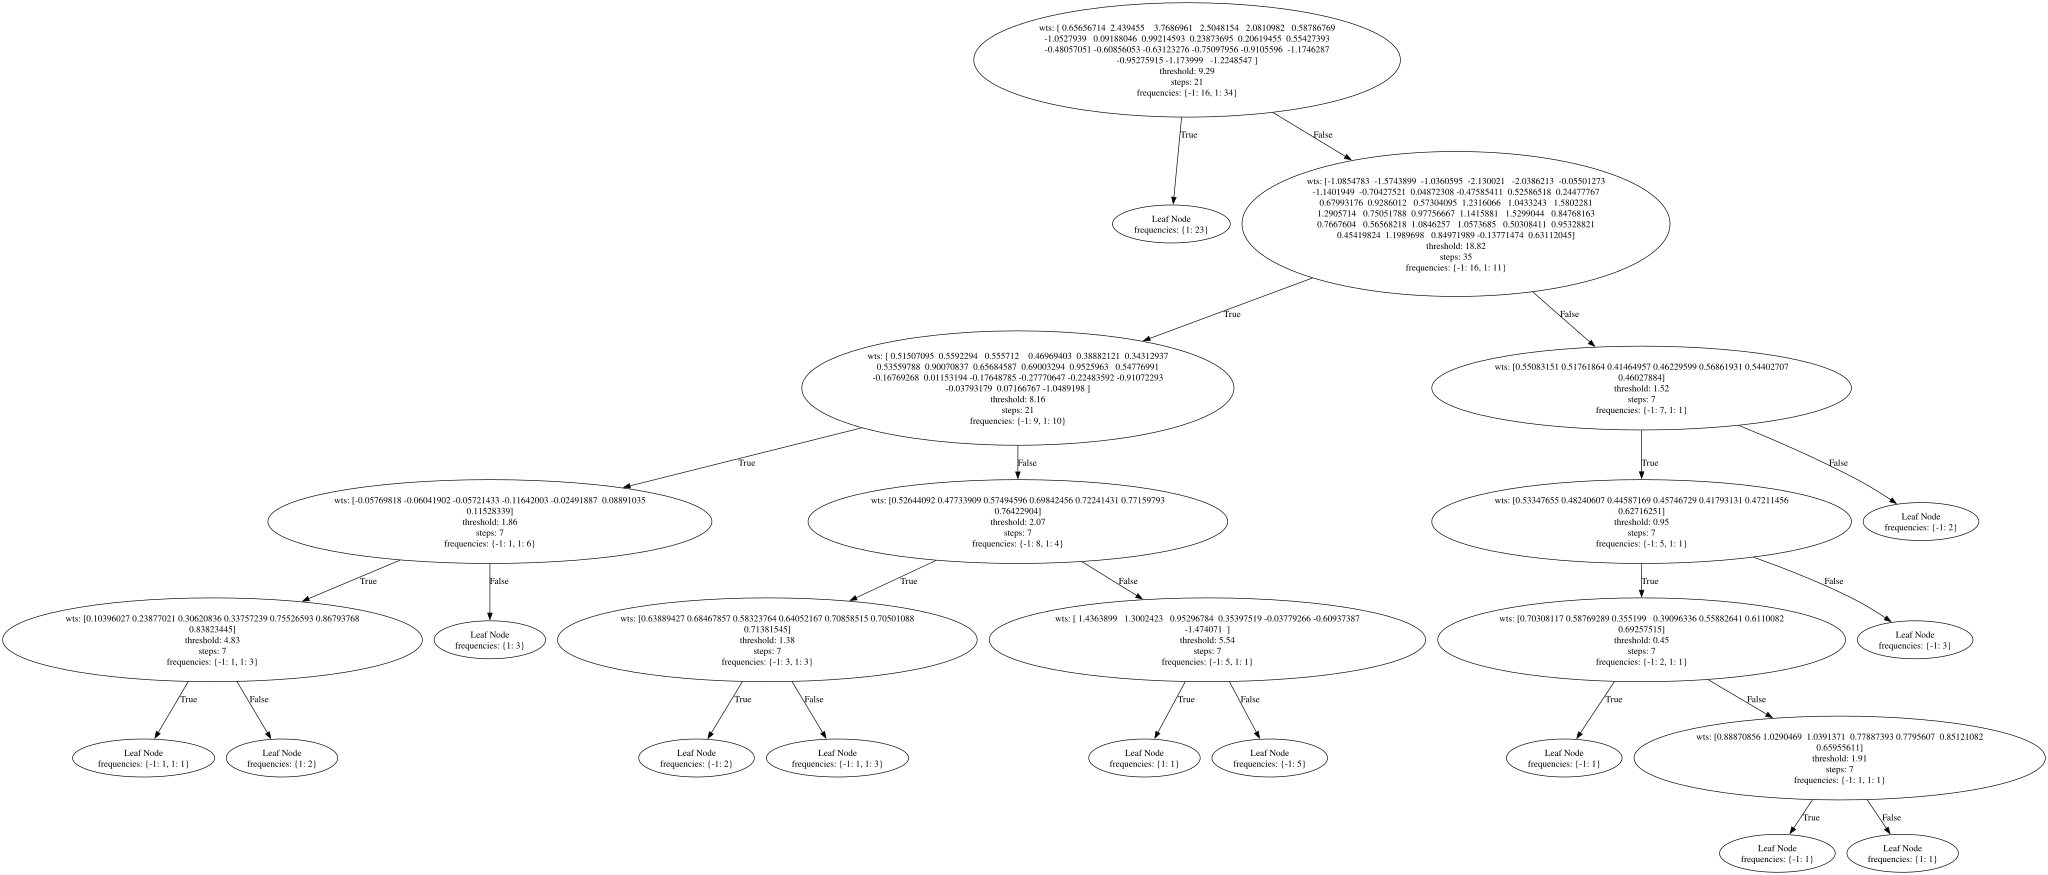

In [40]:
import graphviz

def visualize_step_tree(node, dot=None):
    if dot is None:
        dot = graphviz.Digraph()

    if node.TrueChild is None:
        node_label = 'Leaf Node\n' + ('No Data' if not node.class_distribution else 'frequencies: ' + str(node.class_distribution))
    else:
        node_label = 'wts: {}\nthreshold: {:.2f}\nsteps: {}\n'.format(node.wts, node.threshold, node.steps)
        node_label += 'No Data' if not node.class_distribution else 'frequencies: ' + str(node.class_distribution)

    dot.node(str(id(node)), label=node_label)

    if node.TrueChild is not None:
        dot.edge(str(id(node)), str(id(node.TrueChild)), label='True')
        visualize_step_tree(node.TrueChild, dot)

    if node.FalseChild is not None:
        dot.edge(str(id(node)), str(id(node.FalseChild)), label='False')
        visualize_step_tree(node.FalseChild, dot)

    return dot

dot = visualize_step_tree(Train_example)
dot.render('TS_Step_Tree', format='png', cleanup=True)
dot

In [133]:
# Now let's do a grid search to find the best hyperparameters for the Time Series Step Tree model
# Define the hyperparameters to search
param_grid = {
    'maxstep': [20, 45],
    'stepsize': [7, 15],
    'maxd': [10, 20],
    'mins': [2]
}

# Generate all possible combinations of hyperparameters
grid = ParameterGrid(param_grid)

# Train the Time Series Step Tree model for each hyperparameter combination
results = []
for params in grid:
    Train_example = TS_Step_Tree_Train(X_train, Y_train, params['maxstep'], params['stepsize'], params['maxd'], params['mins'])
    Test_example = TS_Step_Tree_Predict(X_test, Train_example)
    accuracy = accuracy_score(Y_test, Test_example)
    precision = precision_score(Y_test, Test_example)
    recall = recall_score(Y_test, Test_example)
    f1 = f1_score(Y_test, Test_example)
    results.append({
        'maxstep': params['maxstep'],
        'stepsize': params['stepsize'],
        'maxd': params['maxd'],
        'mins': params['mins'],
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

# Display the results
results_df = pd.DataFrame(results)
print(results_df)

KeyboardInterrupt: 

In [160]:
# Now let's train a Random Forest model using the Time Series Step Tree algorithm
def TS_Step_Tree_Random_Forest(X, Y, n_trees=5, maxstep=45, stepsize=15, maxd=20, mins=2):
    """
    Trains a Random Forest model using the Time Series Step Tree algorithm.

    Parameters:
    X (numpy.ndarray): The input time series data.
    Y (numpy.ndarray): The corresponding labels for the time series data.
    n_trees (int): The number of trees in the Random Forest.
    maxstep (int): The maximum size of the steps to consider.
    stepsize (int): The size of the steps to consider.
    maxd (int): The maximum depth of the tree.
    mins (int): The minimum number of samples for splitting.

    Returns:
    list: A list of trained Time Series Step Trees.
    """
    trees = []
    for _ in range(n_trees):
        # Randomly sample the data with replacement
        idx = np.random.choice(len(X), len(X), replace=True)
        X_sample = X[idx]
        Y_sample = Y[idx]
        
        # Train a Time Series Step Tree model
        tree = TS_Step_Tree_Train(X_sample, Y_sample, maxstep, stepsize, maxd, mins)
        trees.append(tree)
    
    return trees

# Train a Random Forest model using the Time Series Step Tree algorithm
forest = TS_Step_Tree_Random_Forest(X_train, Y_train, n_trees=5, maxstep=45, stepsize=15, maxd=20, mins=2)

# Make predictions on the test data
forest_predictions = np.array([TS_Step_Tree_Predict(X_test, tree) for tree in forest])

# Compute the majority vote for each time series
forest_predictions = np.array([max(set(forest_predictions[:, i]), key=list(forest_predictions[:, i]).count) for i in range(len(X_test))])

# Evaluate the test performance of the Random Forest model
accuracy = accuracy_score(Y_test, forest_predictions)
precision = precision_score(Y_test, forest_predictions)
recall = recall_score(Y_test, forest_predictions)
f1 = f1_score(Y_test, forest_predictions)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')


Accuracy: 0.7
Precision: 0.6938775510204082
Recall: 1.0
F1-score: 0.8192771084337349


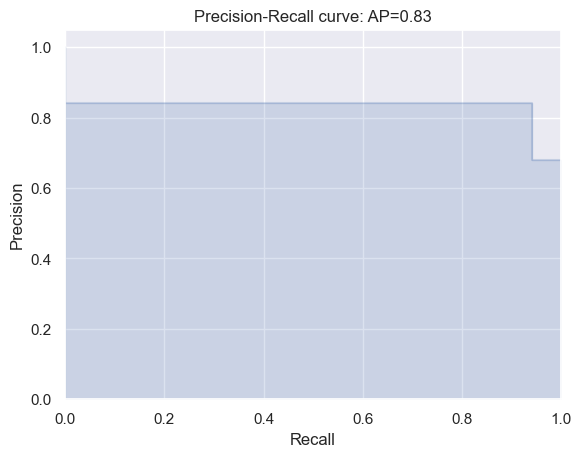

In [161]:
# here we visualize the recall and precision curve for the Time Series Tree model

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

# Compute the average precision score
average_precision = average_precision_score(Y_test, Test_example)

# Compute the precision-recall curve
precision, recall, _ = precision_recall_curve(Y_test, Test_example)

# Plot the precision-recall curve
plt.figure()
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title(f'Precision-Recall curve: AP={average_precision:.2f}')
plt.show()


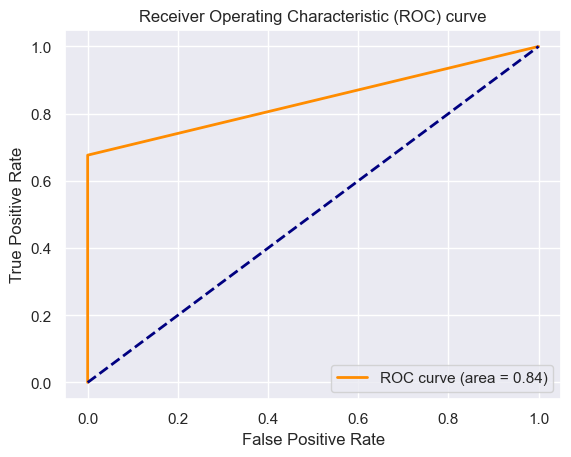

In [57]:
# Here we visualize ROC curve for the Time Series Tree model
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Compute the ROC curve
fpr, tpr, _ = roc_curve(Y_test, Test_example)

# Compute the AUC score
auc = roc_auc_score(Y_test, Test_example)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) curve')
plt.legend(loc='lower right')
plt.show()

In [128]:
d = {1:10000000000000, 2:1000000}
max(d, key=d.get)

1